# **1.Objetivo**


Analisar o comportamento dos clientes de cartão de crédito para identificar
padrões associados à inadimplência e gerar insights estratégicos para o negócio.


# **2. Exploração e limpeza dos dados**

Nesta etapa, exploramos a estrutura dos dados, tipos de variáveis e estatísticas descritivas
para compreender o perfil geral da base.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
tabela_dados = pd.read_csv('/content/Python_M10_support material.csv')

In [3]:
tabela_dados.head()

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,"12.691,51","1.144,90",42
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,"8.256,96","1.291,45",33
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,"3.418,56","1.887,72",20
3,769911858,0,40,F,4,ensino medio,na,menos que $40K,blue,34,3,1,4,"3.313,03","1.171,56",20
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,"4.716,22","816,08",28


In [4]:
tabela_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id                       10127 non-null  int64 
 1   default                  10127 non-null  int64 
 2   idade                    10127 non-null  int64 
 3   sexo                     10127 non-null  object
 4   dependentes              10127 non-null  int64 
 5   escolaridade             10127 non-null  object
 6   estado_civil             10127 non-null  object
 7   salario_anual            10127 non-null  object
 8   tipo_cartao              10127 non-null  object
 9   meses_de_relacionamento  10127 non-null  int64 
 10  qtd_produtos             10127 non-null  int64 
 11  iteracoes_12m            10127 non-null  int64 
 12  meses_inativo_12m        10127 non-null  int64 
 13  limite_credito           10127 non-null  object
 14  valor_transacoes_12m     10127 non-nul

In [5]:
# Primeiro, remove o separador de milhares (ponto) e depois substitui o separador decimal (vírgula) por um ponto
tabela_dados['limite_credito'] = tabela_dados['limite_credito'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
# Converte a coluna 'limite_credito' para numérico, substituindo erros por NaN
tabela_dados['limite_credito'] = pd.to_numeric(tabela_dados['limite_credito'], errors='coerce')

In [6]:
tabela_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       10127 non-null  int64  
 1   default                  10127 non-null  int64  
 2   idade                    10127 non-null  int64  
 3   sexo                     10127 non-null  object 
 4   dependentes              10127 non-null  int64  
 5   escolaridade             10127 non-null  object 
 6   estado_civil             10127 non-null  object 
 7   salario_anual            10127 non-null  object 
 8   tipo_cartao              10127 non-null  object 
 9   meses_de_relacionamento  10127 non-null  int64  
 10  qtd_produtos             10127 non-null  int64  
 11  iteracoes_12m            10127 non-null  int64  
 12  meses_inativo_12m        10127 non-null  int64  
 13  limite_credito           10127 non-null  float64
 14  valor_transacoes_12m  

In [7]:
tabela_dados.describe()

,id,default,idade,dependentes,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,qtd_transacoes_12m
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,0.160660,46.325960,2.346203,35.928409,3.812580,2.455317,2.341167,8632.440165,64.858695
std,3.690378e+07,0.367235,8.016814,1.298908,7.986416,1.554408,1.106225,1.010622,9088.788041,23.472570
min,7.080821e+08,0.000000,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.000000,10.000000
25%,7.130368e+08,0.000000,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.355000,45.000000
50%,7.179264e+08,0.000000,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.420000,67.000000
75%,7.731435e+08,0.000000,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11068.175000,81.000000
max,8.283431e+08,1.000000,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.990000,139.000000


In [8]:
tabela_dados.columns

Index(['id', 'default', 'idade', 'sexo', 'dependentes', 'escolaridade',
       'estado_civil', 'salario_anual', 'tipo_cartao',
       'meses_de_relacionamento', 'qtd_produtos', 'iteracoes_12m',
       'meses_inativo_12m', 'limite_credito', 'valor_transacoes_12m',
       'qtd_transacoes_12m'],
      dtype='object')

In [9]:
tabela_dados.nunique()

,0
id,10127
default,2
idade,45
sexo,2
dependentes,6
escolaridade,6
estado_civil,4
salario_anual,6
tipo_cartao,4
meses_de_relacionamento,44


In [10]:
tabela_dados["escolaridade"].unique()

array(['ensino medio', 'mestrado', 'sem educacao formal', 'na',
       'graduacao', 'doutorado'], dtype=object)

In [11]:
tabela_dados["salario_anual"].unique()

array(['$60K - $80K', 'menos que $40K', '$80K - $120K', '$40K - $60K',
       '$120K +', 'na'], dtype=object)

In [12]:
tabela_dados["tipo_cartao"].unique()

array(['blue', 'gold', 'silver', 'platinum'], dtype=object)

In [13]:
tabela_dados["estado_civil"].unique()

array(['casado', 'solteiro', 'na', 'divorciado'], dtype=object)

In [14]:
tabela_dados.isnull().sum()

,0
id,0
default,0
idade,0
sexo,0
dependentes,0
escolaridade,0
estado_civil,0
salario_anual,0
tipo_cartao,0
meses_de_relacionamento,0




A base é composta por clientes com idade média de 46 anos,
com aproximadamente 2 dependentes e cerca de 3 anos de relacionamento com a instituição.


Trata-se de um público financeiramente ativo, possivelmente com maior nível de
compromissos financeiros.

# **3. Default X Salário**

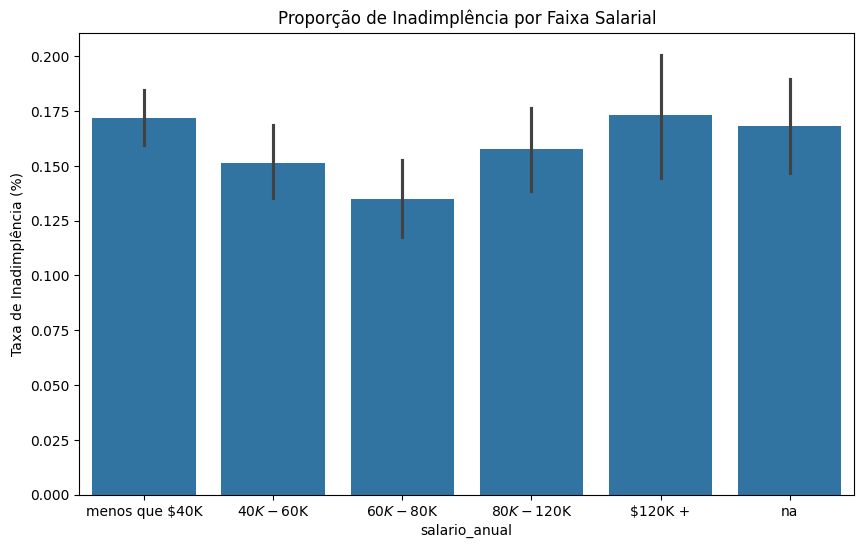

In [15]:
import seaborn as sns
# Ordenando as faixas para o gráfico ficar bonito
ordem_grafico = ['menos que $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +', 'na']

plt.figure(figsize=(10,6))
sns.barplot(x='salario_anual', y='default', data=tabela_dados, order=ordem_grafico)
plt.title('Proporção de Inadimplência por Faixa Salarial')
plt.ylabel('Taxa de Inadimplência (%)')
plt.show()

In [16]:
inad_faixa_salarial = (tabela_dados.groupby('salario_anual')['default'].mean() * 100).reset_index()
inad_faixa_salarial = inad_faixa_salarial.sort_values(by='default', ascending=False)
inad_faixa_salarial

,salario_anual,default
0,$120K +,17.331499
4,menos que $40K,17.186184
5,na,16.816547
3,$80K - $120K,15.765472
1,$40K - $60K,15.139665
2,$60K - $80K,13.480742


In [17]:
# Conta quantas vezes o texto exato 'na' aparece
contagem_na = (tabela_dados['salario_anual'] == 'na').sum()

print(f"Quantidade de 'na' na coluna: {contagem_na}")

Quantidade de 'na' na coluna: 1112


In [18]:
contagem_geral = tabela_dados['salario_anual'].count()
contagem_geral

np.int64(10127)

In [19]:
pocentagem_na = (contagem_na / contagem_geral) * 100
pocentagem_na

np.float64(10.980547052434087)


 A inadimplência apresenta um comportamento não linear em relação à renda, concentrando-se principalmente nos extremos da distribuição. Observa-se maior risco tanto entre clientes de renda mais baixa quanto entre aqueles de renda elevada, enquanto faixas intermediárias mostram maior estabilidade.

 A ausência de informação salarial (“na”) também se destaca como um sinal relevante de risco, indicando que dados incompletos carregam informação importante sobre o perfil financeiro do cliente.




# **4. Default x Escolaridade x Renda**

In [20]:
# Criando a tabela cruzada
relacao_na = pd.crosstab(tabela_dados['escolaridade'], tabela_dados['salario_anual'] == 'na', normalize='index') * 100

# Renomeando as colunas para facilitar a leitura
relacao_na.columns = ['Informou Salário', 'Não Informou (na)']

print(relacao_na)

                     Informou Salário  Não Informou (na)
escolaridade                                            
doutorado                   87.900724          12.099276
ensino medio                88.822653          11.177347
graduacao                   89.338598          10.661402
mestrado                    89.386189          10.613811
na                          90.454246           9.545754
sem educacao formal         87.558843          12.441157


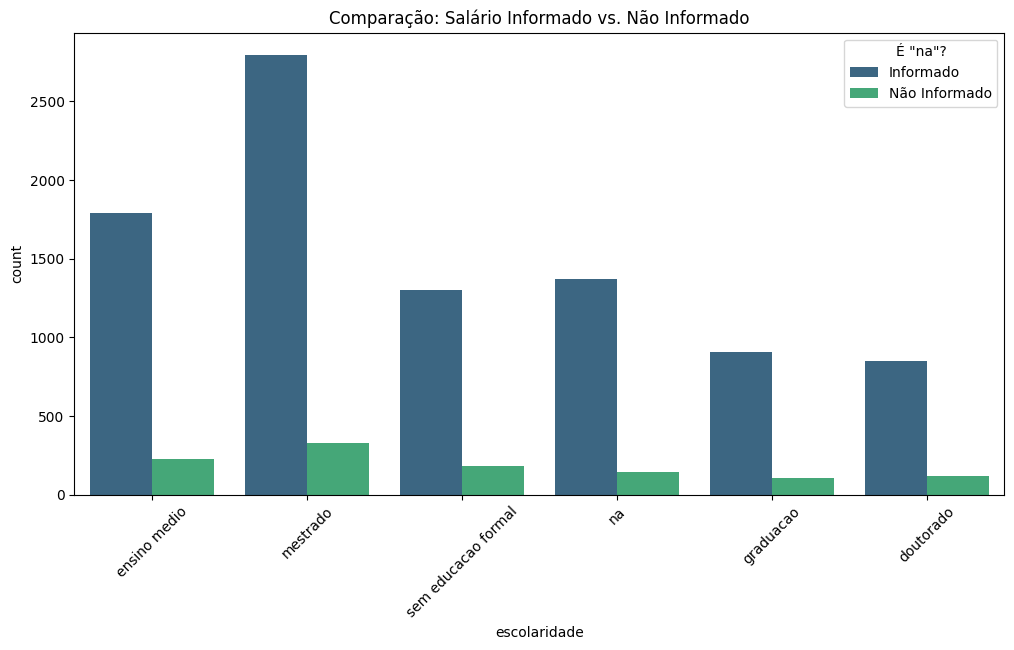

In [21]:
# Criando uma coluna temporária para identificar quem é 'na'
tabela_dados['is_na'] = tabela_dados['salario_anual'] == 'na'

plt.figure(figsize=(12,6))
sns.countplot(x='escolaridade', hue='is_na', data=tabela_dados, palette='viridis')
plt.title('Comparação: Salário Informado vs. Não Informado')
plt.legend(title='É "na"?', labels=['Informado', 'Não Informado'])
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_700/2504104570.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='escolaridade', data=df_na, palette='rocket')


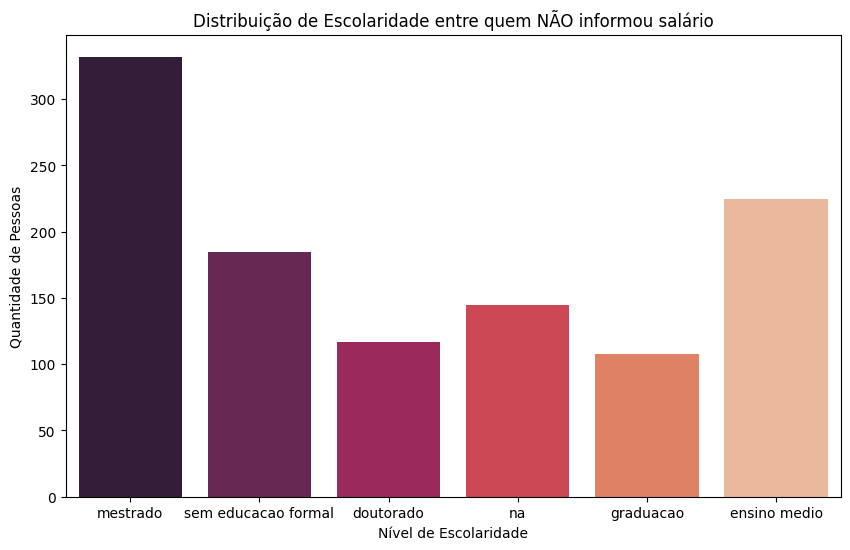

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas quem é 'na' para ver a distribuição por escolaridade
df_na = tabela_dados[tabela_dados['salario_anual'] == 'na']

plt.figure(figsize=(10,6))
sns.countplot(x='escolaridade', data=df_na, palette='rocket')
plt.title('Distribuição de Escolaridade entre quem NÃO informou salário')
plt.xlabel('Nível de Escolaridade')
plt.ylabel('Quantidade de Pessoas')
plt.show()

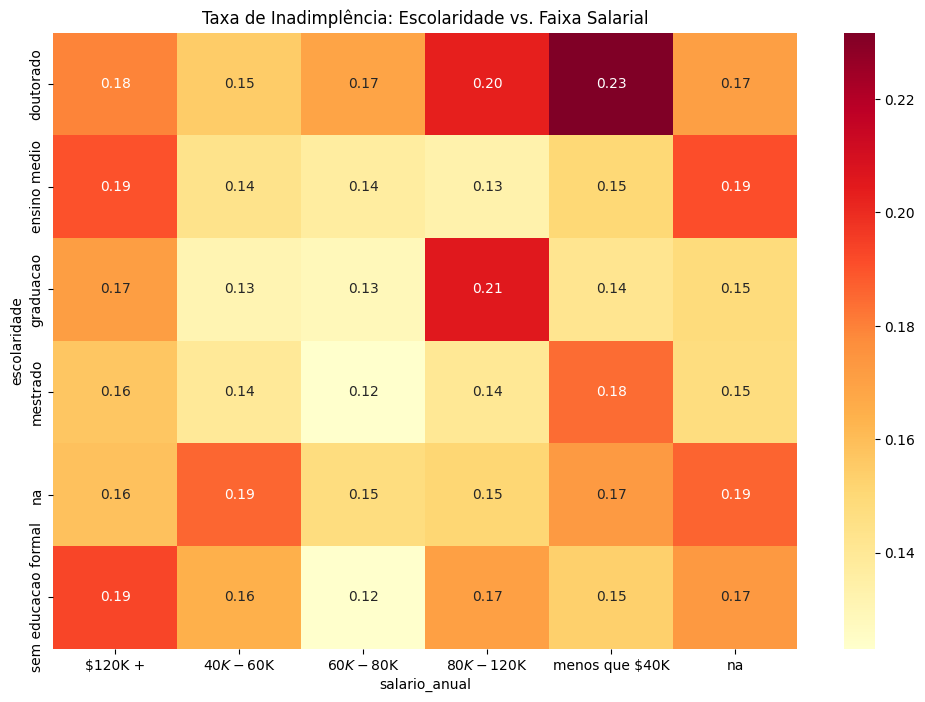

In [23]:
# Criando uma matriz para o Heatmap
pivot_table = tabela_dados.pivot_table(index='escolaridade',
                             columns='salario_anual',
                             values='default',
                             aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Taxa de Inadimplência: Escolaridade vs. Faixa Salarial')
plt.show()

A interação entre escolaridade e renda revela padrões relevantes de inadimplência. Clientes com alta escolaridade e baixa renda apresentam risco elevado, desmistificando a ideia de que maior formação acadêmica implica menor inadimplência.

Além disso, a presença de salários não informados está associada a taxas consistentemente mais altas em diferentes níveis educacionais.

# **5. Faixas de idade x Default**

In [24]:
# Definindo os cortes e as etiquetas corretamente
# Bins: [0-35], [36-46], [47-56], [57-Máximo]
bins = [0, 35, 45, 54, tabela_dados['idade'].max()]
labels = ['Até 35', '36 a 45', '46 a 54', '55+']

tabela_dados['FAIXA_ETARIA'] = pd.cut(tabela_dados['idade'], bins=bins, labels=labels)

# Verificando a distribuição
print(tabela_dados['FAIXA_ETARIA'].value_counts().sort_index())

FAIXA_ETARIA
Até 35      919
36 a 45    3742
46 a 54    3856
55+        1610
Name: count, dtype: int64


In [25]:
tabela_dados

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m,is_na,FAIXA_ETARIA
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,12691.51,"1.144,90",42,False,36 a 45
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,8256.96,"1.291,45",33,False,46 a 54
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,3418.56,"1.887,72",20,False,46 a 54
3,769911858,0,40,F,4,ensino medio,na,menos que $40K,blue,34,3,1,4,3313.03,"1.171,56",20,False,36 a 45
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,4716.22,"816,08",28,False,36 a 45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,0,50,M,2,mestrado,solteiro,$40K - $60K,blue,40,3,3,2,4003.91,"15.476,26",117,False,46 a 54
10123,710638233,1,41,M,2,na,divorciado,$40K - $60K,blue,25,4,3,2,4277.04,"8.764,88",69,False,36 a 45
10124,716506083,1,44,F,1,ensino medio,casado,menos que $40K,blue,36,5,4,3,5409.16,"10.291,78",60,False,36 a 45
10125,717406983,1,30,M,2,mestrado,na,$40K - $60K,blue,36,4,3,3,5281.84,"8.395,62",62,False,Até 35


/tmp/ipykernel_700/4288577313.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FAIXA_ETARIA', y='default', data=tabela_dados, palette='magma')


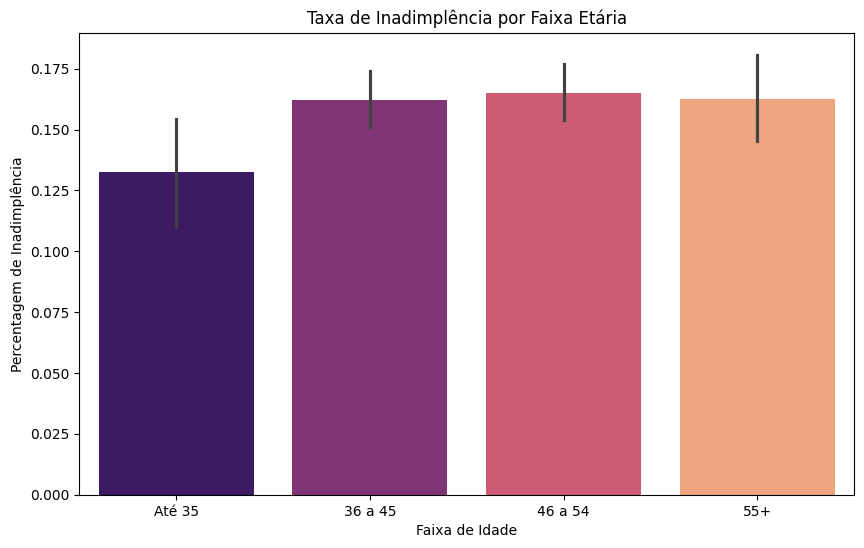

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a taxa de inadimplência por faixa
plt.figure(figsize=(10,6))
sns.barplot(x='FAIXA_ETARIA', y='default', data=tabela_dados, palette='magma')

plt.title('Taxa de Inadimplência por Faixa Etária')
plt.ylabel('Percentagem de Inadimplência')
plt.xlabel('Faixa de Idade')
plt.show()

In [27]:
por_idade = (tabela_dados.groupby('FAIXA_ETARIA')['default'].mean() * 100).reset_index()
por_idade = por_idade.sort_values(by='default', ascending=False)
por_idade

/tmp/ipykernel_700/3126815416.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  por_idade = (tabela_dados.groupby('FAIXA_ETARIA')['default'].mean() * 100).reset_index()


,FAIXA_ETARIA,default
2,46 a 54,16.519710
3,55+,16.273292
1,36 a 45,16.194548
0,Até 35,13.275299


/tmp/ipykernel_700/30894804.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = tabela_dados.pivot_table(index='FAIXA_ETARIA',


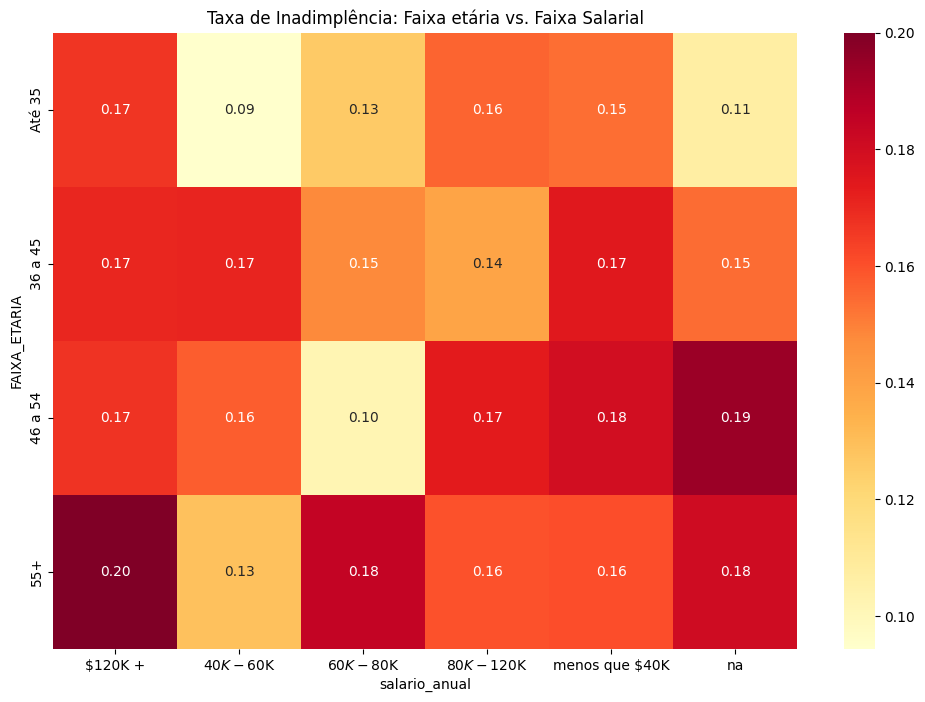

In [28]:
# Criando uma matriz para o Heatmap
pivot_table = tabela_dados.pivot_table(index='FAIXA_ETARIA',
                             columns='salario_anual',
                             values='default',
                             aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Taxa de Inadimplência: Faixa etária vs. Faixa Salarial')
plt.show()

In [29]:
# Isso vai te dar a quantidade exata de pessoas em cada cruzamento
contagem_celulas = pd.crosstab(tabela_dados['FAIXA_ETARIA'], tabela_dados['salario_anual'])

print(contagem_celulas)

salario_anual  $120K +  $40K - $60K  $60K - $80K  $80K - $120K  \
FAIXA_ETARIA                                                     
Até 35              36          180          111            90   
36 a 45            223          691          575           582   
46 a 54            353          616          510           669   
55+                115          303          206           194   

salario_anual  menos que $40K   na  
FAIXA_ETARIA                        
Até 35                    371  131  
36 a 45                  1301  370  
46 a 54                  1285  423  
55+                       604  188  


A inadimplência aumenta com a idade, sendo mais elevada entre clientes a partir de 55 anos. Esse comportamento persiste mesmo em faixas salariais mais altas, indicando que idade e renda não atuam de forma compensatória.

Clientes mais jovens apresentam menor risco, possivelmente devido a limites mais conservadores e menor exposição ao crédito.

## **5.0 Análise de clientes na 55+ que não informaram renda x outras variáveis**

In [30]:
# Isolando o grupo de maior risco
grupo_risco = tabela_dados[(tabela_dados['FAIXA_ETARIA'] == '55+') &
                          (tabela_dados['salario_anual'] == 'na')]

print(f"Total de pessoas nesse grupo: {len(grupo_risco)}")

Total de pessoas nesse grupo: 188


escolaridade
mestrado               31.382979
ensino medio           19.680851
sem educacao formal    17.021277
na                     14.361702
graduacao               9.042553
doutorado               8.510638
Name: proportion, dtype: float64


/tmp/ipykernel_700/1708123895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='escolaridade', data=grupo_risco, palette='magma')


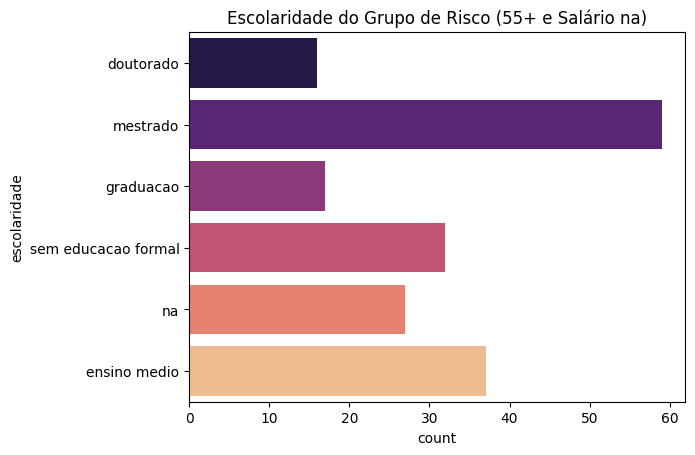

In [31]:
# Verificando a escolaridade nesse grupo específico
escolaridade_risco = grupo_risco['escolaridade'].value_counts(normalize=True) * 100
print(escolaridade_risco)

# Visualizando
sns.countplot(y='escolaridade', data=grupo_risco, palette='magma')
plt.title('Escolaridade do Grupo de Risco (55+ e Salário na)')
plt.show()

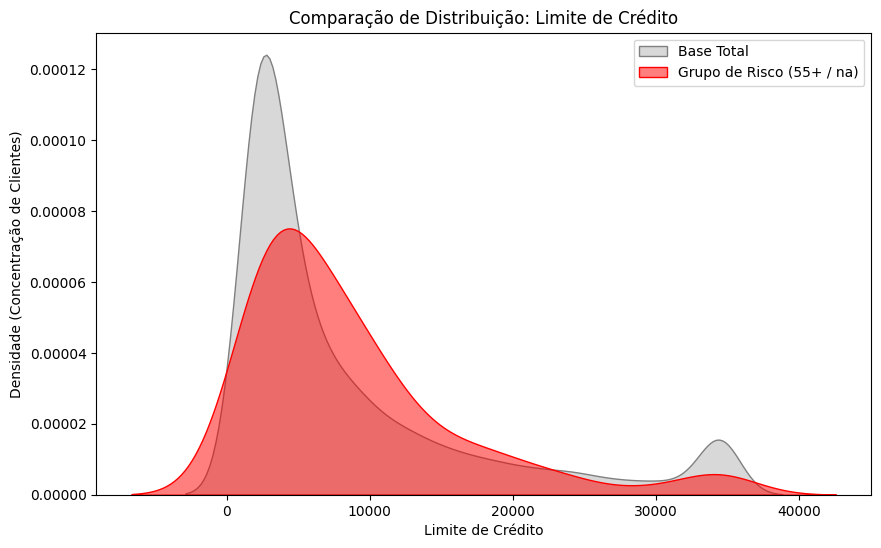

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Ensure 'limite_credito' in tabela_dados is numeric. This was handled in a previous cell
# (uTP5r61uPvKv), but we need to re-create grupo_risco to reflect this change.

# Re-create grupo_risco to ensure it uses the numeric 'limite_credito'
grupo_risco = tabela_dados[(tabela_dados['FAIXA_ETARIA'] == '55+') &
                          (tabela_dados['salario_anual'] == 'na')].copy() # .copy() to avoid SettingWithCopyWarning

# Curva da Base Total
sns.kdeplot(tabela_dados['limite_credito'], label='Base Total', fill=True, color='gray', alpha=0.3)

# Curva do Grupo de Risco
sns.kdeplot(grupo_risco['limite_credito'], label='Grupo de Risco (55+ / na)', fill=True, color='red', alpha=0.5)

plt.title('Comparação de Distribuição: Limite de Crédito')
plt.xlabel('Limite de Crédito')
plt.ylabel('Densidade (Concentração de Clientes)')
plt.legend()
plt.show()

Como esse grupo tem alta escolaridade mas um limite tão baixo, é provável que o banco já tenha identificado algum risco neles anteriormente e restringiu o crédito, ou eles são clientes novos que ainda não provaram capacidade de pagamento.

O grupo de risco está todo amontoado em limites baixos, enquanto os outros clientes estão distribuídos por valores maiores.

Média de transações deste grupo: 61.16


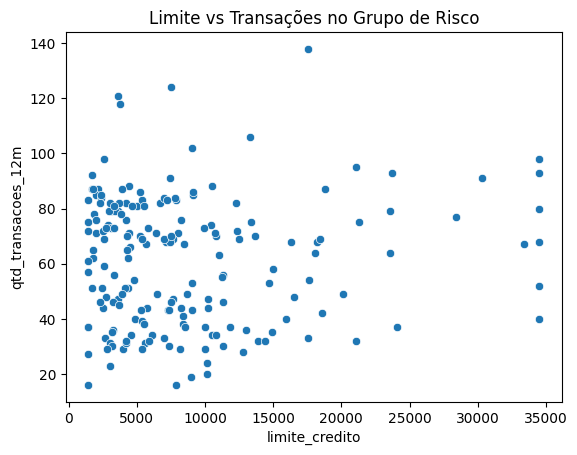

In [33]:
# Exemplo: Média de transações nos últimos 12 meses
media_transacoes = grupo_risco['qtd_transacoes_12m'].mean()
print(f"Média de transações deste grupo: {media_transacoes:.2f}")

# Verificando a relação entre limite e transações
sns.scatterplot(x='limite_credito', y='qtd_transacoes_12m', data=grupo_risco)
plt.title('Limite vs Transações no Grupo de Risco')
plt.show()

O grupo de maior risco apresenta distribuição de limites deslocada para valores mais elevados, indicando que clientes mais inadimplentes não estão necessariamente subcrédito, mas frequentemente superexpostos.

Esse padrão sugere que decisões históricas de concessão não refletem o risco atual desses clientes.

# **6. Faixa de limite**

In [35]:

# Divide em 4 grupos iguais (Quartis)
tabela_dados['FAIXA_LIMITE_QUARTIL'] = pd.qcut(tabela_dados['limite_credito'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

In [36]:
tabela_dados

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m,is_na,FAIXA_ETARIA,FAIXA_LIMITE_QUARTIL
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,12691.51,"1.144,90",42,False,36 a 45,Q4
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,8256.96,"1.291,45",33,False,46 a 54,Q3
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,3418.56,"1.887,72",20,False,46 a 54,Q2
3,769911858,0,40,F,4,ensino medio,na,menos que $40K,blue,34,3,1,4,3313.03,"1.171,56",20,False,36 a 45,Q2
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,4716.22,"816,08",28,False,36 a 45,Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,0,50,M,2,mestrado,solteiro,$40K - $60K,blue,40,3,3,2,4003.91,"15.476,26",117,False,46 a 54,Q2
10123,710638233,1,41,M,2,na,divorciado,$40K - $60K,blue,25,4,3,2,4277.04,"8.764,88",69,False,36 a 45,Q2
10124,716506083,1,44,F,1,ensino medio,casado,menos que $40K,blue,36,5,4,3,5409.16,"10.291,78",60,False,36 a 45,Q3
10125,717406983,1,30,M,2,mestrado,na,$40K - $60K,blue,36,4,3,3,5281.84,"8.395,62",62,False,Até 35,Q3


In [37]:
# Criando o resumo em porcentagem fora do gráfico
resumo_limite = (tabela_dados.groupby('FAIXA_LIMITE_QUARTIL')['default'].mean() * 100).reset_index()
resumo_limite.columns = ['Faixa de Limite', 'Taxa de Inadimplência (%)']

# Formatando para exibir
resumo_limite['Taxa de Inadimplência (%)'] = resumo_limite['Taxa de Inadimplência (%)'].map('{:.2f}%'.format)
print(resumo_limite)

  Faixa de Limite Taxa de Inadimplência (%)
0              Q1                    20.42%
1              Q2                    13.94%
2              Q3                    15.33%
3              Q4                    14.57%


/tmp/ipykernel_700/3529552473.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumo_limite = (tabela_dados.groupby('FAIXA_LIMITE_QUARTIL')['default'].mean() * 100).reset_index()


In [38]:
# O parâmetro retbins=True retorna os valores usados para o corte
tabela_dados['FAIXA_LIMITE_QUARTIL'], bins = pd.qcut(tabela_dados['limite_credito'], q=4, retbins=True)

# Agora vamos ver quais foram os valores:
print(f"Limites dos Quartis: {bins}")

Limites dos Quartis: [ 1438.     2555.355  4549.42  11068.175 34516.99 ]


In [39]:
# Criando os nomes das faixas baseados nos valores reais
labels_reais = [f"R$ {int(bins[i])} - R$ {int(bins[i+1])}" for i in range(len(bins)-1)]

# Aplicando novamente com os nomes claros
tabela_dados['FAIXA_LIMITE_VALOR'] = pd.qcut(tabela_dados['limite_credito'], q=4, labels=labels_reais)

print(tabela_dados['FAIXA_LIMITE_VALOR'].value_counts())

FAIXA_LIMITE_VALOR
R$ 1438 - R$ 2555      2532
R$ 2555 - R$ 4549      2532
R$ 11068 - R$ 34516    2532
R$ 4549 - R$ 11068     2531
Name: count, dtype: int64


In [40]:
tabela_dados

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m,is_na,FAIXA_ETARIA,FAIXA_LIMITE_QUARTIL,FAIXA_LIMITE_VALOR
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,12691.51,"1.144,90",42,False,36 a 45,"(11068.175, 34516.99]",R$ 11068 - R$ 34516
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,8256.96,"1.291,45",33,False,46 a 54,"(4549.42, 11068.175]",R$ 4549 - R$ 11068
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,3418.56,"1.887,72",20,False,46 a 54,"(2555.355, 4549.42]",R$ 2555 - R$ 4549
3,769911858,0,40,F,4,ensino medio,na,menos que $40K,blue,34,3,1,4,3313.03,"1.171,56",20,False,36 a 45,"(2555.355, 4549.42]",R$ 2555 - R$ 4549
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,4716.22,"816,08",28,False,36 a 45,"(4549.42, 11068.175]",R$ 4549 - R$ 11068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,0,50,M,2,mestrado,solteiro,$40K - $60K,blue,40,3,3,2,4003.91,"15.476,26",117,False,46 a 54,"(2555.355, 4549.42]",R$ 2555 - R$ 4549
10123,710638233,1,41,M,2,na,divorciado,$40K - $60K,blue,25,4,3,2,4277.04,"8.764,88",69,False,36 a 45,"(2555.355, 4549.42]",R$ 2555 - R$ 4549
10124,716506083,1,44,F,1,ensino medio,casado,menos que $40K,blue,36,5,4,3,5409.16,"10.291,78",60,False,36 a 45,"(4549.42, 11068.175]",R$ 4549 - R$ 11068
10125,717406983,1,30,M,2,mestrado,na,$40K - $60K,blue,36,4,3,3,5281.84,"8.395,62",62,False,Até 35,"(4549.42, 11068.175]",R$ 4549 - R$ 11068


/tmp/ipykernel_700/3140234668.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = tabela_dados.pivot_table(index='FAIXA_LIMITE_VALOR',


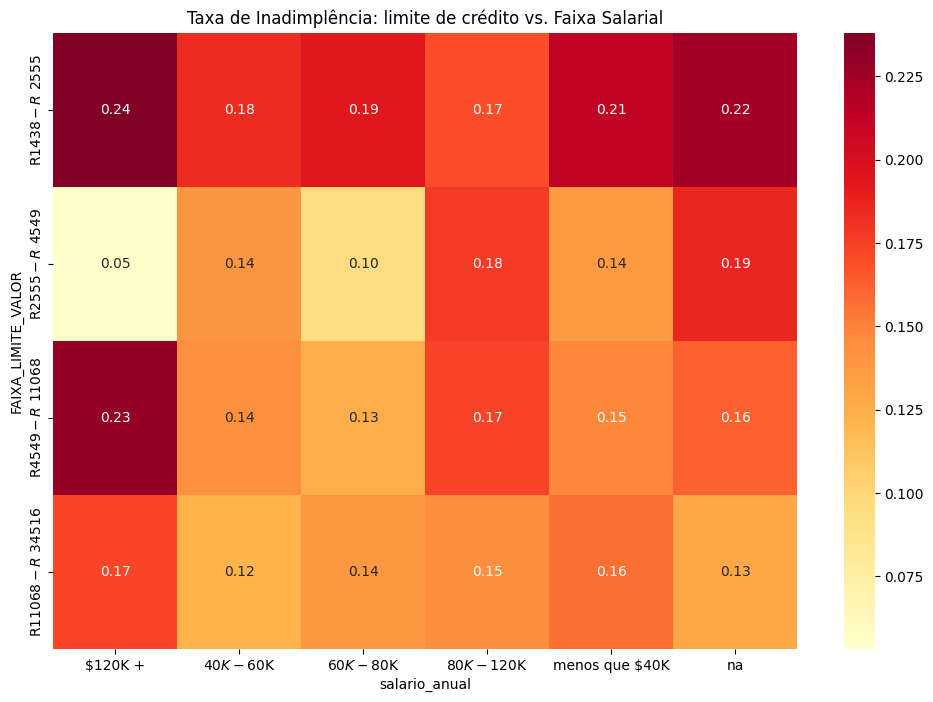

In [41]:
# Criando uma matriz para o Heatmap
pivot_table = tabela_dados.pivot_table(index='FAIXA_LIMITE_VALOR',
                             columns='salario_anual',
                             values='default',
                             aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Taxa de Inadimplência: limite de crédito vs. Faixa Salarial')
plt.show()

Clientes com limites muito baixos concentram as maiores taxas de inadimplência, independentemente da renda. Isso indica que a redução de limite ocorre, muitas vezes, após a deterioração do risco.

O menor risco ocorre quando há alinhamento entre limite concedido e capacidade financeira do cliente.

# **7. Tipo de cartão x Default**

/tmp/ipykernel_700/1088778622.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = tabela_dados.pivot_table(index='tipo_cartao',


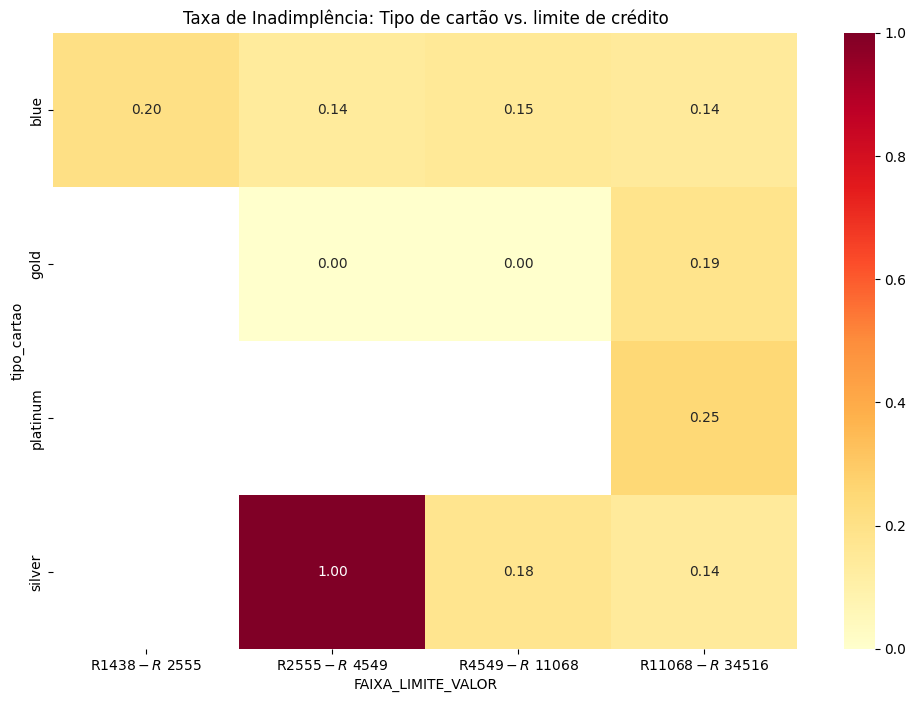

In [42]:
# Criando uma matriz para o Heatmap
pivot_table = tabela_dados.pivot_table(index='tipo_cartao',
                             columns='FAIXA_LIMITE_VALOR',
                             values='default',
                             aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Taxa de Inadimplência: Tipo de cartão vs. limite de crédito')
plt.show()

In [43]:
cont_celulas = pd.crosstab(tabela_dados['tipo_cartao'], tabela_dados['FAIXA_LIMITE_VALOR'])

print(cont_celulas)

FAIXA_LIMITE_VALOR  R$ 1438 - R$ 2555  R$ 2555 - R$ 4549  R$ 4549 - R$ 11068  \
tipo_cartao                                                                    
blue                             2532               2530                2490   
gold                                0                  1                   2   
platinum                            0                  0                   0   
silver                              0                  1                  39   

FAIXA_LIMITE_VALOR  R$ 11068 - R$ 34516  
tipo_cartao                              
blue                               1884  
gold                                113  
platinum                             20  
silver                              515  


In [44]:
# Criando a nova coluna agrupada
tabela_dados['tipo_cartao_agrupado'] = tabela_dados['tipo_cartao'].replace({
    'gold': 'Special',
    'platinum': 'Special',
    'silver': 'Special'
})

# Verificando a nova contagem para garantir que o grupo ficou robusto
print(tabela_dados['tipo_cartao_agrupado'].value_counts())

tipo_cartao_agrupado
blue       9436
Special     691
Name: count, dtype: int64


In [45]:
cont_celulas_2 = pd.crosstab(tabela_dados['tipo_cartao_agrupado'], tabela_dados['FAIXA_LIMITE_VALOR'])

print(cont_celulas_2)

FAIXA_LIMITE_VALOR    R$ 1438 - R$ 2555  R$ 2555 - R$ 4549  \
tipo_cartao_agrupado                                         
Special                               0                  2   
blue                               2532               2530   

FAIXA_LIMITE_VALOR    R$ 4549 - R$ 11068  R$ 11068 - R$ 34516  
tipo_cartao_agrupado                                           
Special                               41                  648  
blue                                2490                 1884  


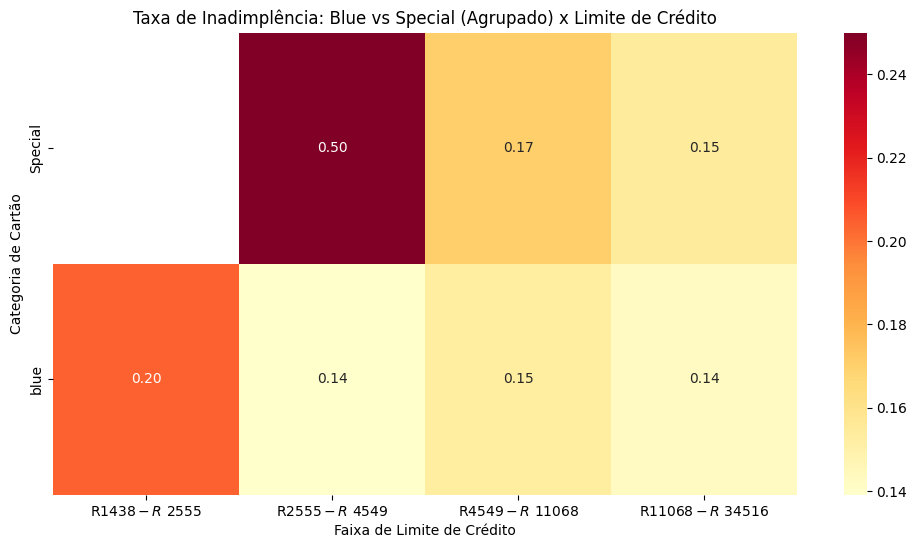

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criando a tabela cruzada com a nova categoria
tabela_final = pd.crosstab(tabela_dados['tipo_cartao_agrupado'], tabela_dados['FAIXA_LIMITE_VALOR'],
                           values=tabela_dados['default'], aggfunc='mean')

plt.figure(figsize=(12, 6))

# vmax=0.25 garante que a escala de cores foque no que importa
sns.heatmap(tabela_final, annot=True, fmt='.2f', cmap='YlOrRd', vmax=0.25)

plt.title('Taxa de Inadimplência: Blue vs Special (Agrupado) x Limite de Crédito')
plt.xlabel('Faixa de Limite de Crédito')
plt.ylabel('Categoria de Cartão')
plt.show()

/tmp/ipykernel_700/477585614.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tipo_cartao', y='default', data=tabela_dados, palette='magma')


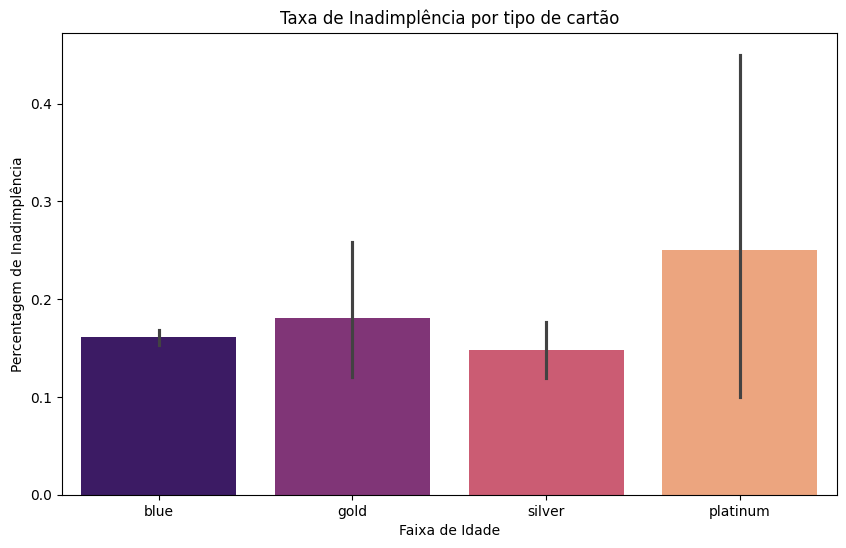

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a taxa de inadimplência por faixa
plt.figure(figsize=(10,6))
sns.barplot(x='tipo_cartao', y='default', data=tabela_dados, palette='magma')

plt.title('Taxa de Inadimplência por tipo de cartão')
plt.ylabel('Percentagem de Inadimplência')
plt.xlabel('Faixa de Idade')
plt.show()

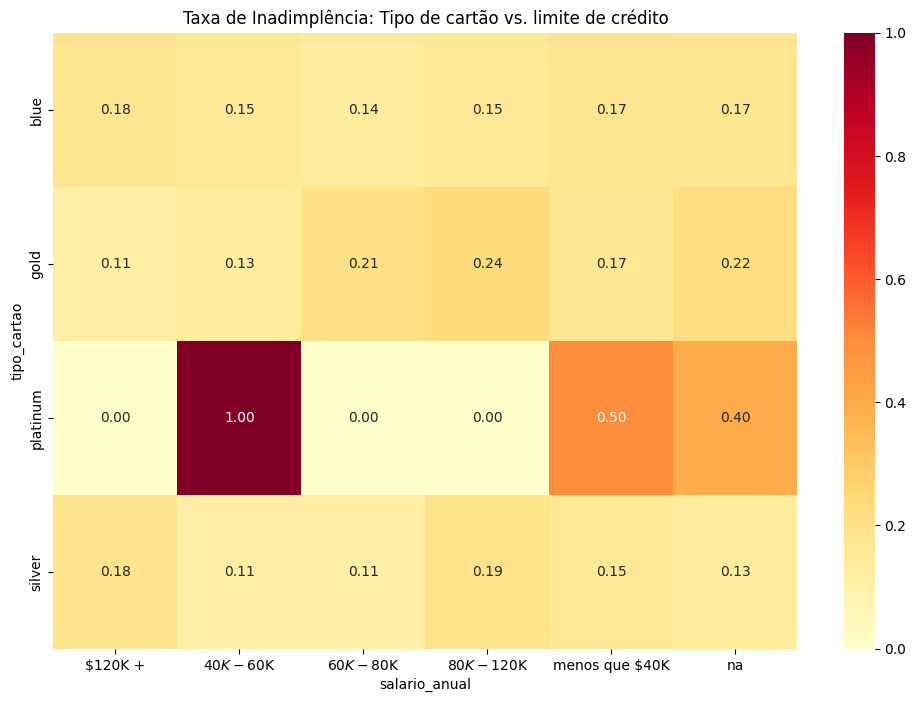

In [48]:
# Criando uma matriz para o Heatmap
pivot_table = tabela_dados.pivot_table(index='tipo_cartao',
                             columns='salario_anual',
                             values='default',
                             aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Taxa de Inadimplência: Tipo de cartão vs. limite de crédito')
plt.show()

In [49]:
cont_celulas2 = pd.crosstab(tabela_dados['tipo_cartao'], tabela_dados['salario_anual'])
print(cont_celulas2)

salario_anual  $120K +  $40K - $60K  $60K - $80K  $80K - $120K  \
tipo_cartao                                                      
blue               645         1675         1273          1395   
gold                18           15           29            21   
platinum             4            1            4             2   
silver              60           99           96           117   

salario_anual  menos que $40K    na  
tipo_cartao                          
blue                     3403  1045  
gold                       24     9  
platinum                    4     5  
silver                    130    53  


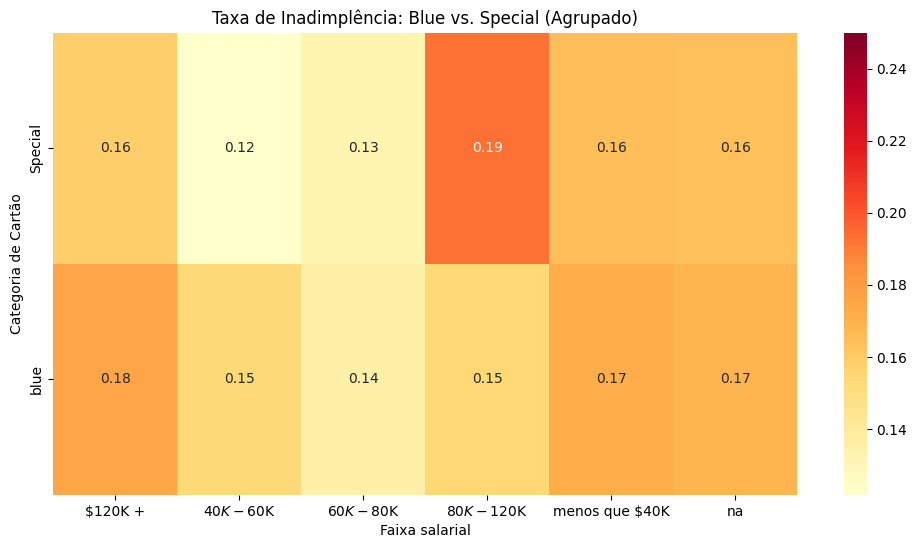

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criando a tabela cruzada com a nova categoria
tabela_final = pd.crosstab(tabela_dados['tipo_cartao_agrupado'], tabela_dados['salario_anual'],
                           values=tabela_dados['default'], aggfunc='mean')

plt.figure(figsize=(12, 6))

# vmax=0.25 garante que a escala de cores foque no que importa
sns.heatmap(tabela_final, annot=True, fmt='.2f', cmap='YlOrRd', vmax=0.25)

plt.title('Taxa de Inadimplência: Blue vs. Special (Agrupado)')
plt.xlabel('Faixa salarial')
plt.ylabel('Categoria de Cartão')
plt.show()

Não há correlação clara entre limite concedido e uso efetivo do cartão. Muitos clientes com limites elevados realizam poucas transações, enquanto clientes com limites menores podem apresentar uso intenso.

A subutilização do limite em grupos de risco indica potencial exposição silenciosa a perdas futuras.

A inadimplência é semelhante entre os diferentes tipos de cartão quando controlada pela renda. Isso mostra que o produto, isoladamente, não é um bom discriminador de risco.

Em determinadas faixas salariais, clientes de cartões considerados “premium” apresentam inadimplência comparável ou superior à de cartões básicos.

# **8. Estado civil x default**

/tmp/ipykernel_700/3781609036.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='estado_civil', y='default', data=tabela_dados, palette='magma')


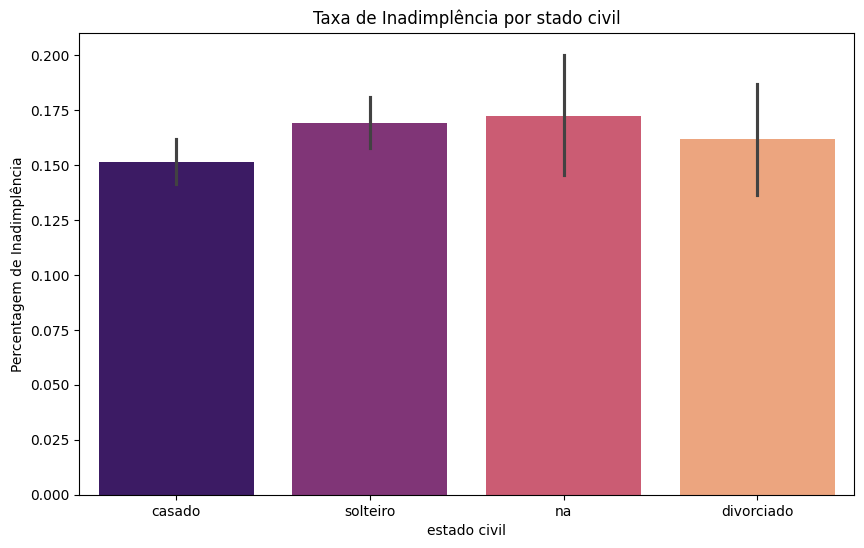

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a taxa de inadimplência por faixa
plt.figure(figsize=(10,6))
sns.barplot(x='estado_civil', y='default', data=tabela_dados, palette='magma')

plt.title('Taxa de Inadimplência por stado civil')
plt.ylabel('Percentagem de Inadimplência')
plt.xlabel('estado civil')
plt.show()

In [52]:
tabela_dados['FAIXA_RELACIONAMENTO_QUARTIL'] = pd.qcut(tabela_dados['meses_de_relacionamento'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

In [53]:
# Criando o resumo em porcentagem fora do gráfico
resumo_relacionamento = (tabela_dados.groupby('FAIXA_RELACIONAMENTO_QUARTIL')['default'].mean() * 100).reset_index()
resumo_relacionamento .columns = ['Faixa de relacionamento', 'Taxa de Inadimplência (%)']

# Formatando para exibir
resumo_relacionamento ['Taxa de Inadimplência (%)'] = resumo_relacionamento ['Taxa de Inadimplência (%)'].map('{:.2f}%'.format)
print(resumo_relacionamento )

  Faixa de relacionamento Taxa de Inadimplência (%)
0                      Q1                    14.70%
1                      Q2                    16.74%
2                      Q3                    16.53%
3                      Q4                    16.19%


/tmp/ipykernel_700/3515910723.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumo_relacionamento = (tabela_dados.groupby('FAIXA_RELACIONAMENTO_QUARTIL')['default'].mean() * 100).reset_index()


In [54]:
# O parâmetro retbins=True retorna os valores usados para o corte
tabela_dados['FAIXA_RELACIONAMENTO_QUARTIL'], bins = pd.qcut(tabela_dados['meses_de_relacionamento'], q=4, retbins=True)

# Agora vamos ver quais foram os valores:
print(f"Limites dos Quartis: {bins}")

Limites dos Quartis: [13. 31. 36. 40. 56.]


In [55]:
# Criando os nomes das faixas baseados nos valores reais
labels_reais = [f" {int(bins[i])} - {int(bins[i+1])}" for i in range(len(bins)-1)]

# Aplicando novamente com os nomes claros
tabela_dados['FAIXA_RELACIONAMENTO'] = pd.qcut(tabela_dados['meses_de_relacionamento'], q=4, labels=labels_reais)

print(tabela_dados['FAIXA_RELACIONAMENTO'].value_counts())

FAIXA_RELACIONAMENTO
31 - 36    3727
13 - 31    2538
40 - 56    2483
36 - 40    1379
Name: count, dtype: int64


/tmp/ipykernel_700/113769858.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FAIXA_RELACIONAMENTO', y='default', data=tabela_dados, palette='magma')


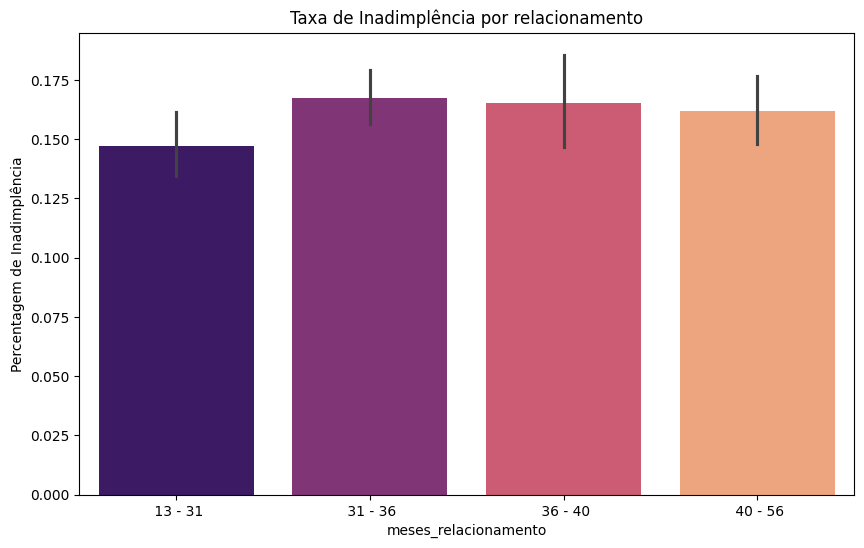

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a taxa de inadimplência por faixa
plt.figure(figsize=(10,6))
sns.barplot(x='FAIXA_RELACIONAMENTO', y='default', data=tabela_dados, palette='magma')

plt.title('Taxa de Inadimplência por relacionamento')
plt.ylabel('Percentagem de Inadimplência')
plt.xlabel('meses_relacionamento')
plt.show()

Clientes com menor tempo de relacionamento apresentam menor inadimplência. O risco cresce após os primeiros anos e se estabiliza em patamares mais elevados nos clientes antigos.

Isso indica que a antiguidade não atua como fator de proteção contra inadimplência.

# **9. Interações x default**

In [57]:
# 1. Limpar e converter 'valor_transacoes_12m' para numérico
# Primeiro, remove o separador de milhares (ponto) e depois substitui o separador decimal (vírgula) por um ponto
tabela_dados['valor_transacoes_12m'] = tabela_dados['valor_transacoes_12m'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
# Converte a coluna para numérico, substituindo erros por NaN
tabela_dados['valor_transacoes_12m'] = pd.to_numeric(tabela_dados['valor_transacoes_12m'], errors='coerce')

# Calcular a taxa de utilização (gastos totais / limite)
# Nota: Como valor_transacoes é o acumulado de 12 meses,
# vamos dividir por 12 para ter uma média mensal e comparar com o limite.
tabela_dados['utilizacao_mensal_media'] = (tabela_dados['valor_transacoes_12m'] / 12) / tabela_dados['limite_credito']

# 2. Criar faixas de utilização para facilitar a leitura
limites_uso = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 100] # 100 para capturar casos acima do limite
labels_uso = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%', '>100%']

tabela_dados['faixa_utilizacao'] = pd.cut(tabela_dados['utilizacao_mensal_media'], bins=limites_uso, labels=labels_uso)

In [58]:
tabela_dados


,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,...,qtd_transacoes_12m,is_na,FAIXA_ETARIA,FAIXA_LIMITE_QUARTIL,FAIXA_LIMITE_VALOR,tipo_cartao_agrupado,FAIXA_RELACIONAMENTO_QUARTIL,FAIXA_RELACIONAMENTO,utilizacao_mensal_media,faixa_utilizacao
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,...,42,False,36 a 45,"(11068.175, 34516.99]",R$ 11068 - R$ 34516,blue,"(36.0, 40.0]",36 - 40,0.007517,0-20%
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,...,33,False,46 a 54,"(4549.42, 11068.175]",R$ 4549 - R$ 11068,blue,"(40.0, 56.0]",40 - 56,0.013034,0-20%
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,...,20,False,46 a 54,"(2555.355, 4549.42]",R$ 2555 - R$ 4549,blue,"(31.0, 36.0]",31 - 36,0.046016,0-20%
3,769911858,0,40,F,4,ensino medio,na,menos que $40K,blue,34,...,20,False,36 a 45,"(2555.355, 4549.42]",R$ 2555 - R$ 4549,blue,"(31.0, 36.0]",31 - 36,0.029468,0-20%
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,...,28,False,36 a 45,"(4549.42, 11068.175]",R$ 4549 - R$ 11068,blue,"(12.999, 31.0]",13 - 31,0.014420,0-20%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,0,50,M,2,mestrado,solteiro,$40K - $60K,blue,40,...,117,False,46 a 54,"(2555.355, 4549.42]",R$ 2555 - R$ 4549,blue,"(36.0, 40.0]",36 - 40,0.322107,20-40%
10123,710638233,1,41,M,2,na,divorciado,$40K - $60K,blue,25,...,69,False,36 a 45,"(2555.355, 4549.42]",R$ 2555 - R$ 4549,blue,"(12.999, 31.0]",13 - 31,0.170774,0-20%
10124,716506083,1,44,F,1,ensino medio,casado,menos que $40K,blue,36,...,60,False,36 a 45,"(4549.42, 11068.175]",R$ 4549 - R$ 11068,blue,"(31.0, 36.0]",31 - 36,0.158555,0-20%
10125,717406983,1,30,M,2,mestrado,na,$40K - $60K,blue,36,...,62,False,Até 35,"(4549.42, 11068.175]",R$ 4549 - R$ 11068,blue,"(31.0, 36.0]",31 - 36,0.132460,0-20%


In [59]:
# Criando a tabela de porcentagem fora do gráfico
analise_uso = (tabela_dados.groupby('faixa_utilizacao')['default'].mean() * 100).reset_index()
analise_uso.columns = ['Uso do Limite', 'Taxa de Inadimplência (%)']

# Formatando para exibição
analise_uso['Taxa de Inadimplência (%)'] = analise_uso['Taxa de Inadimplência (%)'].map('{:.2f}%'.format)

print("Relação entre Uso do Limite e Inadimplência:")
print(analise_uso)

Relação entre Uso do Limite e Inadimplência:
  Uso do Limite Taxa de Inadimplência (%)
0         0-20%                    17.88%
1        20-40%                     0.00%
2        40-60%                     0.00%
3        60-80%                      nan%
4       80-100%                      nan%
5         >100%                      nan%


/tmp/ipykernel_700/3201433983.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analise_uso = (tabela_dados.groupby('faixa_utilizacao')['default'].mean() * 100).reset_index()


/tmp/ipykernel_700/2249166555.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=tabela_dados, x='faixa_utilizacao', y='default', palette='OrRd')


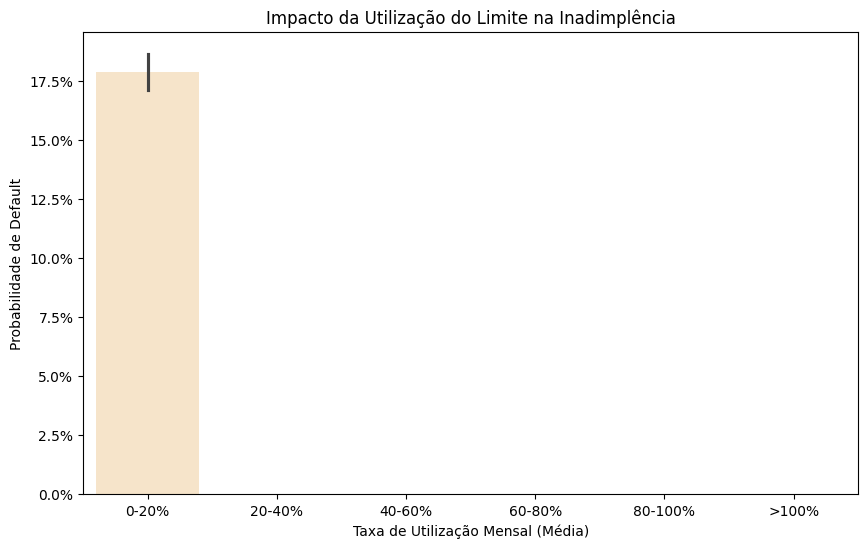

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=tabela_dados, x='faixa_utilizacao', y='default', palette='OrRd')

# Formata o eixo Y para porcentagem
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title('Impacto da Utilização do Limite na Inadimplência')
plt.xlabel('Taxa de Utilização Mensal (Média)')
plt.ylabel('Probabilidade de Default')
plt.show()

In [61]:
# Novos cortes focados na realidade do dado (0 a 100%)
cortes_finos = [0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 1.0]

labels_finos = [
    '0-2%',
    '2-5%',
    '5-10%',
    '10-15%',
    '15-20%',
    '20-25%',
    '25-30%',
    '30-35%',
    '35-40%',
    '>40%'
]

tabela_dados['faixa_utilizacao_fina'] = pd.cut(
    tabela_dados['utilizacao_mensal_media'],
    bins=cortes_finos,
    labels=labels_finos,
    include_lowest=True  # garante que 0 entre na primeira faixa
)

# Verificando a nova distribuição
print(tabela_dados['faixa_utilizacao_fina'].value_counts(dropna=False))

faixa_utilizacao_fina
2-5%      2480
5-10%     2107
0-2%      1998
10-15%    1689
15-20%     826
20-25%     486
25-30%     354
30-35%     123
35-40%      56
>40%         8
Name: count, dtype: int64


In [62]:
analise_uso_2 = (tabela_dados.groupby('faixa_utilizacao_fina')['default'].mean() * 100).reset_index()
analise_uso_2.columns = ['Uso do Limite', 'Taxa de Inadimplência (%)']

# Formatando para exibição
analise_uso_2['Taxa de Inadimplência (%)'] = analise_uso_2['Taxa de Inadimplência (%)'].map('{:.2f}%'.format)

print("Relação entre Uso do Limite e Inadimplência:")
print(analise_uso_2)

Relação entre Uso do Limite e Inadimplência:
  Uso do Limite Taxa de Inadimplência (%)
0          0-2%                    19.27%
1          2-5%                    16.17%
2         5-10%                    19.74%
3        10-15%                    21.43%
4        15-20%                     7.63%
5        20-25%                     0.00%
6        25-30%                     0.00%
7        30-35%                     0.00%
8        35-40%                     0.00%
9          >40%                     0.00%


/tmp/ipykernel_700/3801528463.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analise_uso_2 = (tabela_dados.groupby('faixa_utilizacao_fina')['default'].mean() * 100).reset_index()


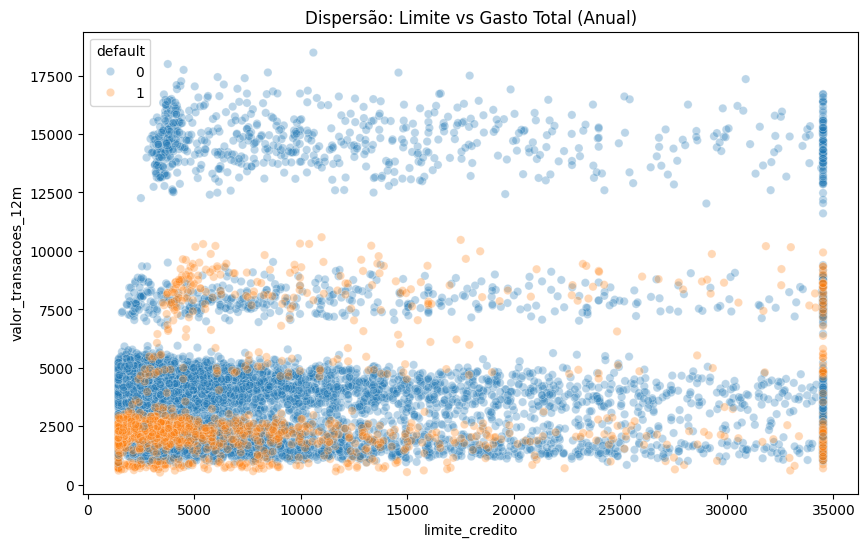

In [63]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tabela_dados, x='limite_credito', y='valor_transacoes_12m', hue='default', alpha=0.3)
plt.title('Dispersão: Limite vs Gasto Total (Anual)')
plt.show()

A inadimplência está fortemente associada ao baixo gasto anual, independentemente do limite disponível. Clientes com gasto recorrente e elevado apresentam menor risco, enquanto clientes inadimplentes tendem a usar pouco o cartão.

Isso mostra que o limite disponível não reflete, necessariamente, o comportamento financeiro real.

In [64]:
# Filtrando apenas quem usa pouco (0-20%) E é inadimplente (default=1)
perfil_risco_baixo_uso = tabela_dados[(tabela_dados['faixa_utilizacao'] == '0-20%') & (tabela_dados['default'] == 1)]

# Verificando a escolaridade desse grupo específico
print(perfil_risco_baixo_uso['escolaridade'].value_counts(normalize=True) * 100)

escolaridade
mestrado               29.932391
ensino medio           18.807621
na                     15.734481
sem educacao formal    14.566687
doutorado              11.493546
graduacao               9.465274
Name: proportion, dtype: float64


In [65]:
# Agrupando por número de interações e calculando a taxa de inadimplência
df_interacoes = (tabela_dados.groupby('iteracoes_12m')['default'].mean() * 100).reset_index()
df_interacoes.columns = ['Quantidade de Interações (12m)', 'Taxa de Inadimplência (%)']

# Formatando a porcentagem
df_interacoes['Taxa de Inadimplência (%)'] = df_interacoes['Taxa de Inadimplência (%)'].map('{:.2f}%'.format)

print("Relatório de Interações vs Inadimplência:")
print(df_interacoes)

Relatório de Interações vs Inadimplência:
   Quantidade de Interações (12m) Taxa de Inadimplência (%)
0                               0                     1.75%
1                               1                     7.20%
2                               2                    12.49%
3                               3                    20.15%
4                               4                    22.63%
5                               5                    33.52%
6                               6                   100.00%


In [66]:
cont_celulas_3 = pd.crosstab(tabela_dados['iteracoes_12m'], tabela_dados['default'])
print(cont_celulas_3)

default           0    1
iteracoes_12m           
0               392    7
1              1391  108
2              2824  403
3              2699  681
4              1077  315
5               117   59
6                 0   54


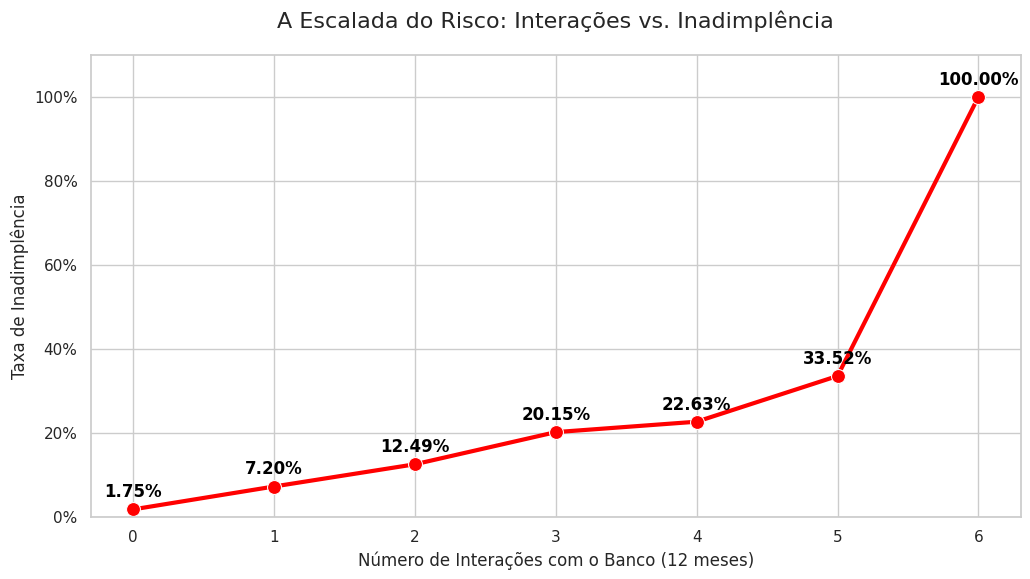

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Configurando o estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Criando o gráfico de linha para mostrar a tendência
paleta = sns.color_palette("Reds", n_colors=7)
ax = sns.lineplot(data=df_interacoes, x='Quantidade de Interações (12m)',
                  y=df_interacoes['Taxa de Inadimplência (%)'].str.replace('%','').astype(float)/100,
                  marker='o', markersize=10, color='red', linewidth=3)

# Adicionando os rótulos de porcentagem em cima de cada ponto
for i in range(df_interacoes.shape[0]):
    valor = df_interacoes['Taxa de Inadimplência (%)'].iloc[i]
    plt.text(i, float(valor.replace('%',''))/100 + 0.03, valor,
             ha='center', fontweight='bold', color='black')

# Formatando o eixo Y para porcentagem
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Títulos e legendas
plt.title('A Escalada do Risco: Interações vs. Inadimplência', fontsize=16, pad=20)
plt.xlabel('Número de Interações com o Banco (12 meses)', fontsize=12)
plt.ylabel('Taxa de Inadimplência', fontsize=12)
plt.ylim(0, 1.1) # Garante espaço para o rótulo de 100%

plt.show()

Existe uma relação direta, crescente e acelerada entre o número de interações com o banco e a inadimplência. A partir da terceira interação, o risco se eleva de forma significativa, atingindo níveis críticos nos maiores volumes de contato.

As interações funcionam como um claro indicador de estresse financeiro.

# **10. Conclusão**

A análise demonstrou que a inadimplência em cartões de crédito é predominantemente explicada por variáveis comportamentais e dinâmicas.

Fatores como uso do cartão, exposição ao crédito e interações com o banco apresentam maior poder explicativo do que características cadastrais isoladas, reforçando a necessidade de políticas de crédito e modelos de risco mais orientados ao comportamento do cliente.